# Medicare Inpatient Model Training - BASELINE on FULL O3 TRAIN Population

**Purpose**: Train Medicare IP prediction model with ONLY baseline features on FULL Medicare population

**Workflow**:
1. Load baseline features (54) + outcomes from FULL Medicare population (with mon_6_include = 1 filter)
2. Split into Train (70%) / Val (15%) / Test (15%)
3. Train XGBoost model with baseline features only (52 features)
4. Generate comprehensive metrics (AUC-ROC, AUC-PR, Brier, Lift @ 1/5/10%)
5. Save model artifacts and metrics CSV for comparison

**Note**: Uses `mon_6_include = 1` filter to match holdout methodology (only members with complete 6-month observation)

**Configuration**:
- **Baseline Only** ⭐: 52 features (chronic conditions, utilization, demographics) ← **Current**
- NO transformer embeddings
- FULL Medicare O3 training population (not just holdout)

**Data Sources**:
- **Baseline Features + Outcomes**: `a834793_Medicare_final_dataset_4_te_experiment` ⭐ **FULL POPULATION**
  - 54 baseline IP model features (HPD, utilization, demographics, etc.)
  - Outcome: Acute IP admission within 6 months (ip6)
  - **FULL Medicare population** (ALL members with IP features, includes training + holdout)
  - Complete population dataset (~millions of members)
  - Features include:
    - HPD scores (CHF, COPD, CV conditions, etc.)
    - Medical utilization (claims, ER visits, unique revenue codes)
    - Demographics (age, gender)
    - Chronic condition flags

**NO EMBEDDINGS USED** - Pure baseline performance on full population

**Key Difference from Other Experiments**:
- **Holdout baseline**: ~2.5M members (90% holdout - NOT in transformer training, mon_6_include = 1)
- **This experiment**: Full population (100% of evaluable members - includes training + holdout, mon_6_include = 1)
- **Key question**: Does including the 10% training sample change baseline performance?
  - If performance is similar → Training sample is representative
  - If worse → Training sample has different characteristics (harder cases, data quality, etc.)
  - If better → Holdout sample had harder cases

**Metrics Generated** (matching reference downstream evaluation):
- AUC-ROC, AUC-PR, Brier Score
- Lift @ 1%, 5%, 10% (precision@k / baseline_prevalence)
- True Positives and Precision at each percentile
- Sample sizes and prevalence rates
- Metrics for Train, Validation, and Test sets

**Expected Results**:
- Baseline only: AUC-ROC ~0.72, Lift@1% ~19x
- With embeddings: Target AUC-ROC >0.80, Lift@1% >18x
- Goal: Quantify lift from transformer embeddings vs. traditional features

**Comparison Framework**:
- Metrics exported to CSV in same format as reference experiments
- Direct comparison with exp2b, exp6, tabular_only, hybrid variants
- Enables identification of best-performing architecture

**Owner**: Pritha Ghosh (pritha.ghosh@cvshealth.com)  
**Team**: Clinical & Social Determinants Intelligence (CSDI)  
**Last Updated**: January 2026

---

## 🔬 **NEW: Ablation Study Support**

This notebook now supports systematic comparison of feature sets:

1. **Baseline Only** (52 features) - Set `FEATURE_SET = "baseline_only"` in Cell 4
2. **Embeddings Only** (256 features) - Set `FEATURE_SET = "embeddings_only"` in Cell 4
3. **Hybrid** (308 features) - Set `FEATURE_SET = "hybrid"` in Cell 4
4. **Production** ⭐ (100 features) - Set `FEATURE_SET = "production"` in Cell 4 ← **Current**

**Enhanced Regularization**: Hyperparameters updated to prevent overfitting:
- Reduced tree depth (7 → 5)
- Increased min_child_weight (10 → 30)
- Added L1/L2 regularization (alpha=0.5, lambda=2.0)
- Row/column subsampling (0.8, 0.6)
- More aggressive early stopping (50 → 30)

**Feature Importance Analysis**: Detailed breakdown by feature type (baseline vs. embeddings)

**Feature Selection**: XGBoost automatically selects important features via tree-based feature importance (no manual pre-filtering)




## 1. Setup & Imports


In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import random
import warnings
import joblib
import gc
from io import BytesIO

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report, brier_score_loss, precision_recall_curve, auc, precision_score, average_precision_score

import xgboost as xgb
from xgboost import XGBClassifier

from scipy.stats import percentileofscore

from google.cloud import storage
from google.cloud import bigquery
import google.auth

import time
from datetime import datetime

random.seed(123)
np.random.seed(123)
warnings.filterwarnings("ignore")
client = bigquery.Client()

print(f"✅ Libraries imported successfully")
print(f"   XGBoost version: {xgb.__version__}")
print(f"   Pandas version: {pd.__version__}")


/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


✅ Libraries imported successfully
   XGBoost version: 3.1.3
   Pandas version: 2.3.3


## 3. Experiment Configuration - Ablation Study


In [2]:
# ============================================================================================
# ABLATION STUDY CONFIGURATION
# Change FEATURE_SET to test different feature combinations
# ============================================================================================

# Options: "baseline_only", "embeddings_only", "hybrid", "production"
FEATURE_SET = "baseline_only"  # ⭐ Control experiment - NO embeddings, baseline features ONLY

# Production-selected embeddings (48 dimensions from production schema)
PRODUCTION_EMBEDDINGS = [
    'embedding_6', 'embedding_7', 'embedding_14', 'embedding_20', 'embedding_23',
    'embedding_30', 'embedding_31', 'embedding_36', 'embedding_43', 'embedding_47',
    'embedding_49', 'embedding_57', 'embedding_64', 'embedding_76', 'embedding_81',
    'embedding_89', 'embedding_94', 'embedding_95', 'embedding_98', 'embedding_104',
    'embedding_110', 'embedding_111', 'embedding_124', 'embedding_126', 'embedding_127',
    'embedding_130', 'embedding_131', 'embedding_138', 'embedding_173', 'embedding_174',
    'embedding_177', 'embedding_178', 'embedding_188', 'embedding_192', 'embedding_195',
    'embedding_203', 'embedding_205', 'embedding_207', 'embedding_212', 'embedding_219',
    'embedding_224', 'embedding_229', 'embedding_230', 'embedding_233', 'embedding_238',
    'embedding_244', 'embedding_253', 'embedding_254'
]

print(f"🔧 Experiment Configuration:")
print(f"   Feature Set: {FEATURE_SET}")
print(f"\n📋 Feature Set Details:")

if FEATURE_SET == "baseline_only":
    print(f"   ✅ Using ONLY baseline features (52 features)")
    print(f"   ❌ Embeddings will be excluded")
    USE_BASELINE = True
    USE_EMBEDDINGS = False
    USE_PRODUCTION_EMBEDDINGS = False
    
elif FEATURE_SET == "embeddings_only":
    print(f"   ❌ Baseline features will be excluded")
    print(f"   ✅ Using ONLY transformer embeddings (256 features)")
    USE_BASELINE = False
    USE_EMBEDDINGS = True
    USE_PRODUCTION_EMBEDDINGS = False
    
elif FEATURE_SET == "hybrid":
    print(f"   ✅ Using baseline features (52 features)")
    print(f"   ✅ Using transformer embeddings (256 features)")
    print(f"   📊 Total: 308 features")
    USE_BASELINE = True
    USE_EMBEDDINGS = True
    USE_PRODUCTION_EMBEDDINGS = False
    
elif FEATURE_SET == "production":
    print(f"   ✅ Using baseline features (52 features)")
    print(f"   ✅ Using PRODUCTION-SELECTED embeddings (48 features)")
    print(f"   📊 Total: 100 features (matches production)")
    print(f"   ℹ️  Production embeddings: emb6, emb7, emb14, ..., emb254")
    USE_BASELINE = True
    USE_EMBEDDINGS = False  # We'll manually select specific embeddings
    USE_PRODUCTION_EMBEDDINGS = True
    
else:
    raise ValueError(f"Invalid FEATURE_SET: {FEATURE_SET}. Must be 'baseline_only', 'embeddings_only', 'hybrid', or 'production'")

print(f"\n{'='*80}")



🔧 Experiment Configuration:
   Feature Set: baseline_only

📋 Feature Set Details:
   ✅ Using ONLY baseline features (52 features)
   ❌ Embeddings will be excluded



## 2. Helper Functions


In [3]:
def plot_roc(y_true, y_pred, model_name='Model'):
    """Plot ROC curve with AUC score"""
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_score = round(roc_auc_score(y_true, y_pred), 3)
    
    plt.figure(figsize=(8, 8))
    text_params = {'ha': 'center', 'va': 'center', 'family': 'sans-serif', 'fontweight': 'bold'}
    lw = 2
    plt.plot(fpr, tpr, color='purple', lw=lw, label=f'{model_name} ROC curve')
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--', alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'Receiver Operating Characteristic - {model_name}', **text_params, fontsize=14)
    plt.legend(loc="lower right")
    plt.text(0.65, 0.2, f'ROC AUC: {roc_score}', size=28, **text_params)
    plt.grid(alpha=0.3)
    plt.show()
    
    return roc_score


def get_metrics(df, y_pred='measure_value', y_true='y_true', calculate_percentile=True, thresh_range=[0.00, 1, 0.01]):
    """Calculate comprehensive metrics across thresholds
    Returns: tp, fp, tn, fn, sensitivity, specificity, ppv, npv, accuracy, lift
    """
    if calculate_percentile:
        df['y_'] = df[y_pred].apply(lambda x: percentileofscore(df[y_pred], x) / 100)
        y_pred = 'y_'
    
    rank_df = pd.DataFrame(
        [(x,
          len(df[(df[y_pred] > x) & (df[y_true] == 1)]),  # tp
          len(df[(df[y_pred] > x) & (df[y_true] == 0)]),  # fp
          len(df[(df[y_pred] < x) & (df[y_true] == 0)]),  # tn
          len(df[(df[y_pred] < x) & (df[y_true] == 1)]),  # fn
         ) for x in np.arange(thresh_range[0], thresh_range[1], thresh_range[2])],
        columns=['threshold', 'tp', 'fp', 'tn', 'fn']
    ).set_index('threshold')
    
    rank_df['sensitivity'] = rank_df['tp'] / (rank_df['tp'] + rank_df['fn'])
    rank_df['ppv'] = rank_df['tp'] / (rank_df['tp'] + rank_df['fp'])
    rank_df['specificity'] = rank_df['tn'] / (rank_df['tn'] + rank_df['fp'])
    rank_df['npv'] = rank_df['tn'] / (rank_df['tn'] + rank_df['fn'])
    rank_df['accuracy'] = (rank_df['tp'] + rank_df['tn']) / (rank_df['tp'] + rank_df['tn'] + rank_df['fp'] + rank_df['fn'])
    rank_df['lift'] = (rank_df['tp'] / (rank_df['tp'] + rank_df['fp'])) / ((rank_df['tp'] + rank_df['fn']) / (rank_df['tp'] + rank_df['tn'] + rank_df['fp'] + rank_df['fn']))
    
    return rank_df.sort_values('threshold', ascending=False)


def preprocess_dataframe(df):
    """Handle missing values and type conversions"""
    print(f"📊 Preprocessing dataframe: {df.shape}")
    
    # Convert target to int
    if 'ip6' in df.columns:
        df['ip6'] = df['ip6'].astype('int')
    
    # Handle float columns
    float32_columns = df.select_dtypes(include=['float32']).columns
    df[float32_columns] = df[float32_columns].fillna(0.0)
    for col in float32_columns:
        df[col] = df[col].astype('float')
    
    float64_columns = df.select_dtypes(include=['float64']).columns
    df[float64_columns] = df[float64_columns].fillna(0.0)
    for col in float64_columns:
        df[col] = df[col].astype('float')
    
    # Handle int columns
    int64_columns = df.select_dtypes(include=['int64']).columns
    df[int64_columns] = df[int64_columns].fillna(0)
    for col in int64_columns:
        df[col] = df[col].astype('int')
    
    # Handle object columns
    object_columns = df.select_dtypes(include=['object']).columns
    for col in object_columns:
        # Replace empty strings with NaN first, then fill with 0
        df[col] = df[col].replace('', np.nan)
    df[object_columns] = df[object_columns].fillna(0)
    for col in object_columns:
        try:
            df[col] = df[col].astype('int')
        except:
            print(f"⚠️  Warning: Could not convert {col} to int, keeping as object")
    
    print(f"✅ Preprocessing complete: {df.shape}")
    return df



# =============================================================================
# COMPREHENSIVE METRICS FUNCTIONS (matching reference implementation)
# =============================================================================

def lift_at_percentage(y_true, y_prob, pct):
    """Calculate lift at top percentile. Lift = precision@k / baseline_prevalence."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    k = max(1, int(n * pct))
    top_k_indices = np.argsort(y_prob)[::-1][:k]
    precision_at_k = y_true[top_k_indices].mean()
    baseline = y_true.mean()
    return precision_at_k / baseline if baseline > 0 else 0.0


def true_positives_at_percentage(y_true, y_prob, pct):
    """Count true positives in top percentile."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    k = max(1, int(n * pct))
    top_k_indices = np.argsort(y_prob)[::-1][:k]
    return int(y_true[top_k_indices].sum())


def precision_at_percentage(y_true, y_prob, pct):
    """Calculate precision at top percentile."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    k = max(1, int(n * pct))
    top_k_indices = np.argsort(y_prob)[::-1][:k]
    return float(y_true[top_k_indices].mean())


def calculate_comprehensive_metrics(y_true, y_pred_proba, set_name="test"):
    """Calculate comprehensive metrics matching reference implementation.
    
    Args:
        y_true: True labels
        y_pred_proba: Predicted probabilities
        set_name: Name of the dataset (train/val/test/oot)
    
    Returns:
        Dictionary of metrics with set_name prefix
    """
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)
    
    # Compute base metrics
    metrics = {
        'auc_roc': roc_auc_score(y_true, y_pred_proba),
        'auc_pr': average_precision_score(y_true, y_pred_proba),
        'brier': brier_score_loss(y_true, y_pred_proba),
        'lift_1pct': lift_at_percentage(y_true, y_pred_proba, 0.01),
        'lift_5pct': lift_at_percentage(y_true, y_pred_proba, 0.05),
        'lift_10pct': lift_at_percentage(y_true, y_pred_proba, 0.10),
        'tp_1pct': true_positives_at_percentage(y_true, y_pred_proba, 0.01),
        'precision_1pct': precision_at_percentage(y_true, y_pred_proba, 0.01),
        'tp_5pct': true_positives_at_percentage(y_true, y_pred_proba, 0.05),
        'precision_5pct': precision_at_percentage(y_true, y_pred_proba, 0.05),
        'tp_10pct': true_positives_at_percentage(y_true, y_pred_proba, 0.10),
        'precision_10pct': precision_at_percentage(y_true, y_pred_proba, 0.10),
        'n_samples': len(y_true),
        'n_positives': int(y_true.sum()),
        'prevalence': float(y_true.mean()),
    }
    
    # Add set_name prefix to all metrics
    prefixed_metrics = {f"{set_name}_{k}": v for k, v in metrics.items()}
    return prefixed_metrics


def create_metrics_summary(all_metrics, feature_set_name, n_features):
    """Create a summary row for the metrics dataframe.
    
    Args:
        all_metrics: Dictionary containing all metrics from different sets
        feature_set_name: Name of feature set (e.g., "baseline_only", "embeddings_only", "hybrid")
        n_features: Number of features used
    
    Returns:
        Dictionary with all metrics
    """
    summary = {
        "exp_name": feature_set_name,
        "model_type": "XGBoost",
        "feature_set": feature_set_name,
        "n_features": n_features
    }
    summary.update(all_metrics)
    return summary


print("✅ Helper functions defined")


✅ Helper functions defined


## 3. Load Training Data


In [4]:
# Step 1: SKIP embedding loading for baseline-only experiment
print("📥 Step 1: SKIPPING transformer embeddings (baseline-only experiment)")
print("   ⚠️  NO EMBEDDINGS will be loaded or used")
print("   ✅ This ensures we use the FULL holdout dataset (not just members with embeddings)")
print("")
print("   Baseline dataset: ~2.5M members")
print("   vs. Embedding experiments: ~761K members (subset with embeddings)")
print("")
print("   This is a TRUE baseline - no selection bias from embedding availability")


📥 Step 1: SKIPPING transformer embeddings (baseline-only experiment)
   ⚠️  NO EMBEDDINGS will be loaded or used
   ✅ This ensures we use the FULL holdout dataset (not just members with embeddings)

   Baseline dataset: ~2.5M members
   vs. Embedding experiments: ~761K members (subset with embeddings)

   This is a TRUE baseline - no selection bias from embedding availability


## 3b. Load Baseline Features + Join with Embeddings


In [5]:
# Step 2: Load baseline features + outcomes from FULL Medicare population
print("\n📥 Step 2: Loading baseline features + outcomes from BigQuery...")
print("   Source: a834793_Medicare_final_dataset_4_te_experiment ⭐ FULL MEDICARE POPULATION")
start_time = time.time()

baseline_sql = """
    SELECT 
        individual_id,
        index_dt,
        member_id,
        ip6,
        sum_ip6_admits,
        sum_ip6_los,
        mon_6_include,
        -- HPD features
        camemhpd_aff, camemhpd_alc, camemhpd_cbd, camemhpd_chf, camemhpd_chr_flag,
        camemhpd_cop, camemhpd_crf, camemhpd_cv_cond, camemhpd_dia, camemhpd_hyp, camemhpd_ngd,
        -- Medical Utilization
        camemmedutilization_clm_ln_cnt, camemmedutilization_er_clm_cnt,
        camemmedutilization_uniq_dx_cd_cnt, camemmedutilization_uniq_rev_cd_cnt,
        -- Medical Case
        camemmedcasedc1_ip_cnt_dc1, camemmedcasedc1_ip_days_dc1,
        camemmedcasedc2_ip_cnt_dc2, camemmedcasedc2_ip_days_dc2, camemmedcasedc3_ip_cnt_dc3,
        -- Diagnosis
        camemeipdxdc1_dxc1085_cnt_dc1,
        -- Procedures
        camemeipprcdc1_prc141_cnt_dc1, camemeipprcdc1_prc155_cnt_dc1,
        camemeipprcdc1_prc219_cnt_dc1, camemeipprcdc1_prcc1102_cnt_dc1, camemeipprcdc1_prcc1115_cnt_dc1,
        -- Revenue Codes
        camemrevenuedc3_rev730_cnt_dc3, camemrevenuedc4_rev430_cnt_dc4,
        -- ER/UC
        camemerucdc1_erclm_cnt_dc1, camemerucdc2_erclm_cnt_dc2,
        -- RX Class
        camemrxclassutilizationdc5_anticonvulsants_misc_flag_dc5,
        camemrxclassutilizationdc5_loop_diuretics_flag_dc5,
        -- RX Group
        camemrxgrouputilizationdc1_antidepressants_days_dc1,
        camemrxgrouputilizationdc1_corticosteroids_days_dc1,
        camemrxgrouputilizationdc2_anticonvulsants_days_dc2,
        camemrxgrouputilizationdc2_corticosteroids_days_dc2,
        camemrxgrouputilizationdc3_anticonvulsants_flag_dc3,
        -- Specialty Claims
        camemspcclmdc1_spcclmwhos_cnt_dc1, camemspcclmdc2_spcclmwhos_cnt_dc2,
        camemspcofcdc3_spcd_cnt_dc3,
        -- Care Management
        camemtgtptpdc2_cm_soe, camemtgtptpdc5_cm_soe,
        -- Text Notes
        camemtxtnotesdc5_txt_end_dc5, camemtxtnotesdc5_txt_short_dc5,
        -- YLM Demographics
        camemylm_ylm_homeagesourcer, camemylm_ylm_orent,
        camemylm_ylm_tw_hvalsecinv, camemylm_ylm_tw_hvyinvtrad,
        -- Membership Demographics
        camemmbrshp_age65_74, camemmbrshp_agenbr,
        -- Expenditure
        e_caperetdem21220, e_caperetdem444
    FROM `edp-prod-storage.edp_ent_sdoheir_cns.a834793_Medicare_final_dataset_4_te_experiment`
    WHERE mon_6_include = 1  -- Only members with full 6-month observation (same as holdout)
    -- This ensures fair comparison with holdout results
"""

df_baseline = client.query(baseline_sql).to_dataframe()
load_time_2 = time.time() - start_time

print(f"✅ Baseline features loaded: {df_baseline.shape[0]:,} rows, {df_baseline.shape[1]} columns")
print(f"   Load time: {load_time_2:.1f} seconds")



📥 Step 2: Loading baseline features + outcomes from BigQuery...
   Source: a834793_Medicare_final_dataset_4_te_experiment ⭐ FULL MEDICARE POPULATION


✅ Baseline features loaded: 3,059,018 rows, 59 columns
   Load time: 12.1 seconds


In [6]:
# Step 3: SKIP embedding join for baseline-only experiment
print("\n🔗 Step 3: Using baseline features ONLY (no embedding join)")
print(f"   ✅ Using FULL holdout dataset: {df_baseline.shape[0]:,} rows")
print(f"   ⚠️  NO EMBEDDING JOIN - this is the complete baseline population")
print(f"   ")
print(f"   Key difference from other experiments:")
print(f"      Baseline-only: {df_baseline.shape[0]:,} members (100% of holdout)")
print(f"      Embedding experiments: ~761K members (30% of holdout - only those with embeddings)")
print(f"   ")
print(f"   This ensures NO selection bias from embedding availability!")

# Use baseline dataframe directly (no join needed)
df = df_baseline.copy()

# Clean up memory
del df_baseline
gc.collect()

# Check outcome distribution
print(f"\n📊 Outcome distribution:")
print(df['ip6'].value_counts())
print(f"   IP rate: {df['ip6'].mean()*100:.2f}%")
print(f"\n🧹 Memory cleaned up")

# ============================================================================================
# SELECTIVE EMBEDDING FEATURES - N/A for baseline-only experiment
# ============================================================================================

print("\nℹ️  Embedding selection: N/A (baseline-only experiment - no embeddings loaded)")
print(f"\n{'='*80}")



🔗 Step 3: Using baseline features ONLY (no embedding join)
   ✅ Using FULL holdout dataset: 3,059,018 rows
   ⚠️  NO EMBEDDING JOIN - this is the complete baseline population
   
   Key difference from other experiments:
      Baseline-only: 3,059,018 members (100% of holdout)
      Embedding experiments: ~761K members (30% of holdout - only those with embeddings)
   
   This ensures NO selection bias from embedding availability!

📊 Outcome distribution:
ip6
0    2858890
1     200128
Name: count, dtype: Int64
   IP rate: 6.54%

🧹 Memory cleaned up

ℹ️  Embedding selection: N/A (baseline-only experiment - no embeddings loaded)



## 4. Feature Selection & Preprocessing


In [7]:
# Define baseline features (54 total) - matches SQL query in data loading step
baseline_features = [
    # HPD Chronic Conditions (11 features)
    'camemhpd_aff', 'camemhpd_alc', 'camemhpd_cbd', 'camemhpd_chf', 'camemhpd_chr_flag',
    'camemhpd_cop', 'camemhpd_crf', 'camemhpd_cv_cond', 'camemhpd_dia', 'camemhpd_hyp', 'camemhpd_ngd',
    
    # Medical Utilization (4 features)
    'camemmedutilization_clm_ln_cnt', 'camemmedutilization_er_clm_cnt',
    'camemmedutilization_uniq_dx_cd_cnt', 'camemmedutilization_uniq_rev_cd_cnt',
    
    # Medical Case (5 features)
    'camemmedcasedc1_ip_cnt_dc1', 'camemmedcasedc1_ip_days_dc1',
    'camemmedcasedc2_ip_cnt_dc2', 'camemmedcasedc2_ip_days_dc2', 'camemmedcasedc3_ip_cnt_dc3',
    
    # Diagnosis (1 feature)
    'camemeipdxdc1_dxc1085_cnt_dc1',
    
    # Procedures (5 features)
    'camemeipprcdc1_prc141_cnt_dc1', 'camemeipprcdc1_prc155_cnt_dc1',
    'camemeipprcdc1_prc219_cnt_dc1', 'camemeipprcdc1_prcc1102_cnt_dc1', 'camemeipprcdc1_prcc1115_cnt_dc1',
    
    # Revenue Codes (2 features)
    'camemrevenuedc3_rev730_cnt_dc3', 'camemrevenuedc4_rev430_cnt_dc4',
    
    # ER/UC (2 features)
    'camemerucdc1_erclm_cnt_dc1', 'camemerucdc2_erclm_cnt_dc2',
    
    # RX Class (2 features)
    'camemrxclassutilizationdc5_anticonvulsants_misc_flag_dc5',
    'camemrxclassutilizationdc5_loop_diuretics_flag_dc5',
    
    # RX Group (5 features)
    'camemrxgrouputilizationdc1_antidepressants_days_dc1',
    'camemrxgrouputilizationdc1_corticosteroids_days_dc1',
    'camemrxgrouputilizationdc2_anticonvulsants_days_dc2',
    'camemrxgrouputilizationdc2_corticosteroids_days_dc2',
    'camemrxgrouputilizationdc3_anticonvulsants_flag_dc3',
    
    # Specialty Claims (3 features)
    'camemspcclmdc1_spcclmwhos_cnt_dc1', 'camemspcclmdc2_spcclmwhos_cnt_dc2',
    'camemspcofcdc3_spcd_cnt_dc3',
    
    # Care Management (2 features)
    'camemtgtptpdc2_cm_soe', 'camemtgtptpdc5_cm_soe',
    
    # Text Notes (2 features)
    'camemtxtnotesdc5_txt_end_dc5', 'camemtxtnotesdc5_txt_short_dc5',
    
    # YLM Demographics (4 features)
    'camemylm_ylm_homeagesourcer', 'camemylm_ylm_orent',
    'camemylm_ylm_tw_hvalsecinv', 'camemylm_ylm_tw_hvyinvtrad',
    
    # Membership Demographics (2 features)
    'camemmbrshp_age65_74', 'camemmbrshp_agenbr',
    
    # Expenditure (2 features)
    'e_caperetdem21220', 'e_caperetdem444'
]

print(f"📋 Defined {len(baseline_features)} baseline features")
print(f"   Categories: HPD (11), Medical Util (4), Medical Case (5), Diagnosis (1),")
print(f"               Procedures (5), Revenue (2), ER/UC (2), RX Class (2),")
print(f"               RX Group (5), Specialty (3), Care Mgmt (2), Text Notes (2),")
print(f"               YLM Demo (4), Membership (2), Expenditure (2)")



📋 Defined 52 baseline features
   Categories: HPD (11), Medical Util (4), Medical Case (5), Diagnosis (1),
               Procedures (5), Revenue (2), ER/UC (2), RX Class (2),
               RX Group (5), Specialty (3), Care Mgmt (2), Text Notes (2),
               YLM Demo (4), Membership (2), Expenditure (2)


In [8]:
# Check which baseline features are actually in the dataset
available_features = [f for f in baseline_features if f in df.columns]
missing_features = [f for f in baseline_features if f not in df.columns]

if missing_features:
    print(f"\n⚠️  Warning: {len(missing_features)} baseline features not found")
    for f in missing_features[:5]:  # Show first 5
        print(f"      - {f}")
    
print(f"✅ {len(available_features)} baseline features available for training")

# Identify embedding features (256 dimensions)
# Pattern: embedding_0, embedding_1, ..., embedding_255
embedding_features = [col for col in df.columns if col.startswith('embedding_') and col.split('_')[1].isdigit()]
embedding_features = sorted(embedding_features, key=lambda x: int(x.split('_')[1]))  # Sort numerically

print(f"\n🔢 Found {len(embedding_features)} embedding features")
if embedding_features:
    print(f"   Range: {embedding_features[0]} to {embedding_features[-1]}")

# Combine all features
if USE_PRODUCTION_EMBEDDINGS:
    # Production configuration: baseline + 48 selected embeddings
    production_emb_available = [f for f in PRODUCTION_EMBEDDINGS if f in df.columns]
    all_features = available_features + production_emb_available
    exp_name = 'production'
    print(f"\n✅ Using PRODUCTION configuration:")
    print(f"   - Baseline: {len(available_features)}")
    print(f"   - Production embeddings available: {len(production_emb_available)}/{len(PRODUCTION_EMBEDDINGS)}")
    if len(production_emb_available) < len(PRODUCTION_EMBEDDINGS):
        missing_embs = set(PRODUCTION_EMBEDDINGS) - set(production_emb_available)
        print(f"   ⚠️  Missing {len(missing_embs)} production embeddings")
elif USE_BASELINE and USE_EMBEDDINGS:
    all_features = available_features + embedding_features
    exp_name = 'hybrid'
elif USE_BASELINE:
    all_features = available_features
    exp_name = 'baseline_only'
elif USE_EMBEDDINGS:
    all_features = embedding_features
    exp_name = 'embeddings_only'
else:
    raise ValueError('Must enable at least one feature set!')


print(f"\n📊 Total features for training: {len(all_features)}")
if USE_PRODUCTION_EMBEDDINGS:
    print(f"   - Baseline: {len(available_features)}")
    print(f"   - Production embeddings: {len(production_emb_available)}")
elif USE_BASELINE and USE_EMBEDDINGS:
    print(f"   - Baseline: {len(available_features)}")
    print(f"   - Embeddings: {len(embedding_features)}")
elif USE_BASELINE:
    print(f"   - Baseline: {len(available_features)} (embeddings excluded)")
elif USE_EMBEDDINGS:
    print(f"   - Embeddings: {len(embedding_features)} (baseline excluded)")


✅ 52 baseline features available for training

🔢 Found 0 embedding features

📊 Total features for training: 52
   - Baseline: 52 (embeddings excluded)


In [9]:
# Preprocess dataframe
df = preprocess_dataframe(df)
print(df.head())

# Prepare features and target
X = df[all_features]  # Use all_features instead of available_features
y = df['ip6']
ids = df['individual_id']

print(f"\n📊 Feature matrix: {X.shape}")
print(f"   Features selected: {len(all_features)}")
if USE_BASELINE and USE_EMBEDDINGS:
    print(f"     - Baseline: {len(available_features)}")
    print(f"     - Embeddings: {len(embedding_features)}")
elif USE_BASELINE:
    print(f"     - Baseline only: {len(available_features)}")
elif USE_EMBEDDINGS:
    print(f"     - Embeddings only: {len(embedding_features)}")
print(f"   Target vector: {y.shape}")
print(f"   Positive class rate: {y.mean()*100:.2f}%")

# CRITICAL: Standardize embeddings (they're continuous, not counts like baseline)
if USE_EMBEDDINGS and not USE_BASELINE:
    from sklearn.preprocessing import StandardScaler
    print(f"\n🔧 Standardizing embeddings (mean=0, std=1)...")
    print(f"   Before: mean={X.mean().mean():.3f}, std={X.std().mean():.3f}")
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
    
    print(f"   After:  mean={X.mean().mean():.3f}, std={X.std().mean():.3f}")
    print(f"   ✅ Embeddings standardized")


📊 Preprocessing dataframe: (3059018, 59)
✅ Preprocessing complete: (3059018, 59)
      individual_id    index_dt       member_id  ip6  sum_ip6_admits  \
0  7059947856264164  2023-05-16  10136703920098    0               0   
1        9755314416  2023-05-16  10136560080098    0               0   
2          97128849  2023-09-16  10123344400098    0               0   
3   394229354986096  2023-11-16  10153266190098    0               0   
4   627916981758511  2023-03-16  10111773660098    0               0   

   sum_ip6_los  mon_6_include  camemhpd_aff  camemhpd_alc  camemhpd_cbd  ...  \
0            0              1             0             0             0  ...   
1            0              1             1             0             0  ...   
2            0              1             0             0             0  ...   
3            0              1             0             0             0  ...   
4            0              1             0             0             0  ...   

   ca

## 5. Train/Val/Test Split


In [10]:
# Split data: 70% train, 15% val, 15% test
# First split: 70% train, 30% temp (val + test)
X_train, X_temp, y_train, y_temp, ids_train, ids_temp = train_test_split(
    X, y, ids, 
    test_size=0.30, 
    random_state=199,
    stratify=y  # Maintain class balance
)

# Second split: Split temp into 50% val, 50% test (15% each of total)
X_val, X_test, y_val, y_test, ids_val, ids_test = train_test_split(
    X_temp, y_temp, ids_temp,
    test_size=0.50,
    random_state=199,
    stratify=y_temp
)

print(f"📊 Train/Val/Test Split:")
print(f"   Training set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation set: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"   Training IP rate: {y_train.mean()*100:.2f}%")
print(f"   Validation IP rate: {y_val.mean()*100:.2f}%")
print(f"   Test IP rate: {y_test.mean()*100:.2f}%")

# Create DMatrix for XGBoost
dtrain_clf = xgb.DMatrix(X_train, y_train)
dval_clf = xgb.DMatrix(X_val, y_val)
dtest_clf = xgb.DMatrix(X_test, y_test)
print(f"\n✅ Created XGBoost DMatrix objects")


📊 Train/Val/Test Split:
   Training set: 2,141,312 samples (70.0%)
   Validation set: 458,853 samples (15.0%)
   Test set: 458,853 samples (15.0%)
   Training IP rate: 6.54%
   Validation IP rate: 6.54%
   Test IP rate: 6.54%

✅ Created XGBoost DMatrix objects


## 6. Model Training - XGBoost

**Hyperparameters** (based on production model `param_a`):
- `objective`: binary:logistic
- `max_depth`: 7 (deep trees for complex interactions)
- `min_child_weight`: 10 (conservative, prevents overfitting)
- `eta`: 0.01 (learning rate - slow for better generalization)
- `subsample`: 1.0 (use all samples)
- `colsample_bytree`: 0.7 (70% of features per tree)
- `tree_method`: hist (fast histogram-based algorithm)
- `grow_policy`: lossguide (best-first tree growth)
- `num_boost_round`: 1000 (number of trees)


In [11]:
# Define hyperparameters - OPTIMIZED FOR EMBEDDINGS vs BASELINE
if USE_EMBEDDINGS and not USE_BASELINE:
    # EMBEDDINGS-ONLY: Balance performance vs generalization
    print("🔧 Using EMBEDDINGS-OPTIMIZED hyperparameters (regularized)")
    params = {
        'objective': 'binary:logistic',
        'max_depth': 4,  # Shallow trees to prevent overfitting (was 7)
        'min_child_weight': 50,  # Strong regularization (was 5)
        'eta': 0.01,  # Slow learning rate to prevent overfitting (was 0.02)
        'subsample': 0.7,  # Aggressive row sampling (was 0.9)
        'colsample_bytree': 0.5,  # Aggressive column sampling (was 0.8)
        'lambda': 3.0,  # Strong L2 regularization (was 0.5)
        'alpha': 1.0,  # Strong L1 regularization (was 0.1)
        'gamma': 1.0,  # Min loss reduction to split (NEW - prevents weak splits)
        'scale_pos_weight': 14.4,  # Handle 6.48% imbalance
        'tree_method': 'hist',
        'grow_policy': 'depthwise',  # Changed from lossguide (more conservative)
        'eval_metric': 'auc',
        'seed': 123
    }
else:
    # BASELINE or HYBRID: EXTREME regularization to prevent overfitting
    print("🔧 Using BASELINE/HYBRID hyperparameters (EXTREME regularization)")
    params = {
        'objective': 'binary:logistic',
        'max_depth': 3,  # Very shallow (was 5) - limit complexity
        'min_child_weight': 100,  # Very high (was 30) - prevent tiny splits
        'eta': 0.005,  # Very slow learning (was 0.01) - prevent overfitting
        'subsample': 0.6,  # Aggressive row sampling (was 0.8)
        'colsample_bytree': 0.4,  # Aggressive column sampling (was 0.6)
        'lambda': 5.0,  # Very strong L2 (was 2.0)
        'alpha': 2.0,  # Very strong L1 (was 0.5)
        'gamma': 2.0,  # High min loss reduction (was 0)
        'max_delta_step': 1,  # Limit weight updates
        'tree_method': 'hist',
        'grow_policy': 'depthwise',  # More conservative (was lossguide)
        'eval_metric': 'auc',
        'seed': 123
    }

print("🔧 XGBoost Hyperparameters:")
for k, v in params.items():
    print(f"   {k}: {v}")


🔧 Using BASELINE/HYBRID hyperparameters (EXTREME regularization)
🔧 XGBoost Hyperparameters:
   objective: binary:logistic
   max_depth: 3
   min_child_weight: 100
   eta: 0.005
   subsample: 0.6
   colsample_bytree: 0.4
   lambda: 5.0
   alpha: 2.0
   gamma: 2.0
   max_delta_step: 1
   tree_method: hist
   grow_policy: depthwise
   eval_metric: auc
   seed: 123


In [12]:
# Train model with validation set for early stopping
print("\n🚀 Training XGBoost model...")
start_time = time.time()

bst = xgb.train(
    params, 
    dtrain_clf, 
    num_boost_round=5000,  # Very high for eta=0.005
    evals=[(dtrain_clf, 'train'), (dval_clf, 'val')],
    early_stopping_rounds=100,  # Very patient early stopping
    verbose_eval=100
)

training_time = time.time() - start_time
print(f"\n✅ Training complete in {training_time:.1f} seconds ({training_time/60:.1f} minutes)")
print(f"   Best iteration: {bst.best_iteration}")
print(f"   Best score: {bst.best_score:.4f}")



🚀 Training XGBoost model...
[0]	train-auc:0.65422	val-auc:0.65462
[100]	train-auc:0.71781	val-auc:0.71729
[200]	train-auc:0.72066	val-auc:0.71978
[300]	train-auc:0.72359	val-auc:0.72242
[400]	train-auc:0.72694	val-auc:0.72550
[500]	train-auc:0.72994	val-auc:0.72829
[600]	train-auc:0.73217	val-auc:0.73033
[700]	train-auc:0.73393	val-auc:0.73197
[800]	train-auc:0.73523	val-auc:0.73311
[900]	train-auc:0.73624	val-auc:0.73401
[1000]	train-auc:0.73705	val-auc:0.73474
[1100]	train-auc:0.73764	val-auc:0.73527
[1200]	train-auc:0.73815	val-auc:0.73575
[1300]	train-auc:0.73858	val-auc:0.73613
[1400]	train-auc:0.73895	val-auc:0.73645
[1500]	train-auc:0.73926	val-auc:0.73673
[1600]	train-auc:0.73954	val-auc:0.73698
[1700]	train-auc:0.73979	val-auc:0.73721
[1800]	train-auc:0.74001	val-auc:0.73740
[1900]	train-auc:0.74020	val-auc:0.73756
[2000]	train-auc:0.74037	val-auc:0.73770
[2100]	train-auc:0.74053	val-auc:0.73785
[2200]	train-auc:0.74067	val-auc:0.73797
[2300]	train-auc:0.74082	val-auc:0.73809

## 7. Model Evaluation


In [13]:
# Generate predictions for all sets
print("\n📊 Generating predictions for all datasets...")

y_pred_train = bst.predict(dtrain_clf)
y_pred_val = bst.predict(dval_clf)
y_pred_test = bst.predict(dtest_clf)

print(f"✅ Predictions generated")
print(f"   Train: {len(y_pred_train):,} predictions")
print(f"   Val: {len(y_pred_val):,} predictions")
print(f"   Test: {len(y_pred_test):,} predictions")

# Calculate comprehensive metrics for all sets
print("\n📊 Calculating comprehensive metrics...")

train_metrics = calculate_comprehensive_metrics(y_train, y_pred_train, "train")
val_metrics = calculate_comprehensive_metrics(y_val, y_pred_val, "val")
test_metrics = calculate_comprehensive_metrics(y_test, y_pred_test, "test")

# Combine all metrics
all_metrics = {}
all_metrics.update(train_metrics)
all_metrics.update(val_metrics)
all_metrics.update(test_metrics)

# Display key metrics
print("\n" + "="*80)
print("📊 MODEL PERFORMANCE SUMMARY")
print("="*80)

print(f"\n🎯 AUC-ROC:")
print(f"   Train: {train_metrics['train_auc_roc']:.4f}")
print(f"   Val:   {val_metrics['val_auc_roc']:.4f}")
print(f"   Test:  {test_metrics['test_auc_roc']:.4f}")

print(f"\n📈 AUC-PR:")
print(f"   Train: {train_metrics['train_auc_pr']:.4f}")
print(f"   Val:   {val_metrics['val_auc_pr']:.4f}")
print(f"   Test:  {test_metrics['test_auc_pr']:.4f}")

print(f"\n📉 Brier Score (lower is better):")
print(f"   Train: {train_metrics['train_brier']:.4f}")
print(f"   Val:   {val_metrics['val_brier']:.4f}")
print(f"   Test:  {test_metrics['test_brier']:.4f}")

print(f"\n🎯 Lift @ Top 1%:")
print(f"   Train: {train_metrics['train_lift_1pct']:.2f}x  ({train_metrics['train_tp_1pct']} TP, {train_metrics['train_precision_1pct']*100:.2f}% precision)")
print(f"   Val:   {val_metrics['val_lift_1pct']:.2f}x  ({val_metrics['val_tp_1pct']} TP, {val_metrics['val_precision_1pct']*100:.2f}% precision)")
print(f"   Test:  {test_metrics['test_lift_1pct']:.2f}x  ({test_metrics['test_tp_1pct']} TP, {test_metrics['test_precision_1pct']*100:.2f}% precision)")

print(f"\n🎯 Lift @ Top 5%:")
print(f"   Train: {train_metrics['train_lift_5pct']:.2f}x  ({train_metrics['train_tp_5pct']} TP, {train_metrics['train_precision_5pct']*100:.2f}% precision)")
print(f"   Val:   {val_metrics['val_lift_5pct']:.2f}x  ({val_metrics['val_tp_5pct']} TP, {val_metrics['val_precision_5pct']*100:.2f}% precision)")
print(f"   Test:  {test_metrics['test_lift_5pct']:.2f}x  ({test_metrics['test_tp_5pct']} TP, {test_metrics['test_precision_5pct']*100:.2f}% precision)")

print(f"\n🎯 Lift @ Top 10%:")
print(f"   Train: {train_metrics['train_lift_10pct']:.2f}x  ({train_metrics['train_tp_10pct']} TP, {train_metrics['train_precision_10pct']*100:.2f}% precision)")
print(f"   Val:   {val_metrics['val_lift_10pct']:.2f}x  ({val_metrics['val_tp_10pct']} TP, {val_metrics['val_precision_10pct']*100:.2f}% precision)")
print(f"   Test:  {test_metrics['test_lift_10pct']:.2f}x  ({test_metrics['test_tp_10pct']} TP, {test_metrics['test_precision_10pct']*100:.2f}% precision)")

print("\n" + "="*80)

# Check for overfitting
train_val_gap = train_metrics['train_auc_roc'] - val_metrics['val_auc_roc']
if train_val_gap > 0.05:
    print(f"⚠️  Warning: Potential overfitting detected (train-val gap: {train_val_gap:.4f})")
else:
    print(f"✅ Good generalization (train-val gap: {train_val_gap:.4f})")



📊 Generating predictions for all datasets...


✅ Predictions generated
   Train: 2,141,312 predictions
   Val: 458,853 predictions
   Test: 458,853 predictions

📊 Calculating comprehensive metrics...

📊 MODEL PERFORMANCE SUMMARY

🎯 AUC-ROC:
   Train: 0.7429
   Val:   0.7396
   Test:  0.7436

📈 AUC-PR:
   Train: 0.2038
   Val:   0.2000
   Test:  0.2011

📉 Brier Score (lower is better):
   Train: 0.0569
   Val:   0.0570
   Test:  0.0570

🎯 Lift @ Top 1%:
   Train: 6.47x  (9059 TP, 42.31% precision)
   Val:   6.28x  (1884 TP, 41.06% precision)
   Test:  6.22x  (1866 TP, 40.67% precision)

🎯 Lift @ Top 5%:
   Train: 4.24x  (29716 TP, 27.76% precision)
   Val:   4.18x  (6272 TP, 27.34% precision)
   Test:  4.20x  (6311 TP, 27.51% precision)

🎯 Lift @ Top 10%:
   Train: 3.36x  (47007 TP, 21.95% precision)
   Val:   3.30x  (9913 TP, 21.60% precision)
   Test:  3.33x  (9995 TP, 21.78% precision)

✅ Good generalization (train-val gap: 0.0033)


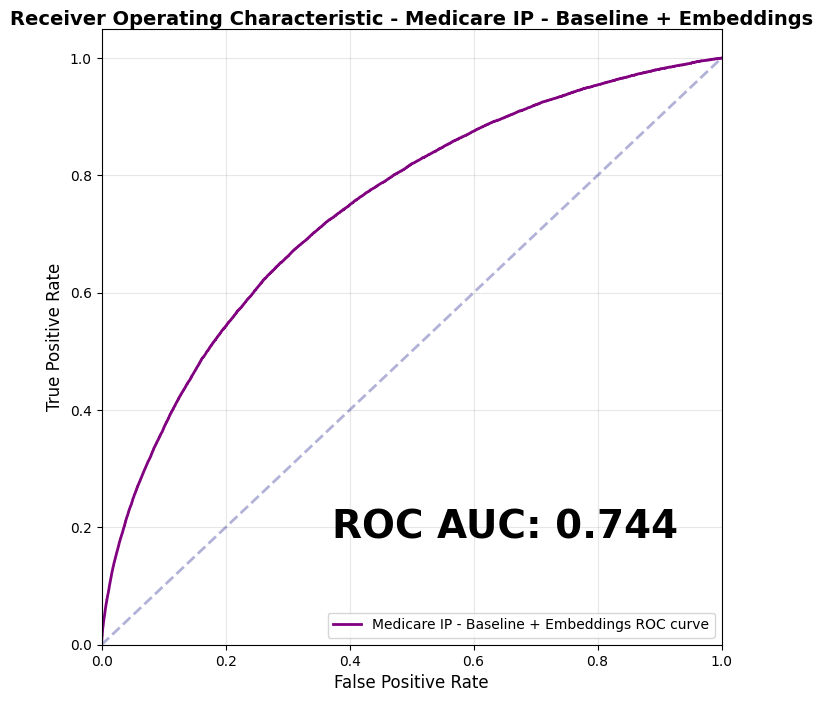


📊 Metrics Summary DataFrame:
                                   0
exp_name               baseline_only
model_type                   XGBoost
feature_set            baseline_only
n_features                        52
train_auc_roc               0.742927
train_auc_pr                  0.2038
train_brier                 0.056885
train_lift_1pct             6.466593
train_lift_5pct             4.242439
train_lift_10pct            3.355489
train_tp_1pct                   9059
train_precision_1pct        0.423061
train_tp_5pct                  29716
train_precision_5pct        0.277551
train_tp_10pct                 47007
train_precision_10pct       0.219524
train_n_samples              2141312
train_n_positives             140090
train_prevalence            0.065423
val_auc_roc                 0.739647
val_auc_pr                  0.199972
val_brier                    0.05704
val_lift_1pct                6.27675
val_lift_5pct               4.178805
val_lift_10pct              3.302264
val_tp_1

In [14]:
# Plot ROC curve for test set
test_roc_score = plot_roc(y_test, y_pred_test, model_name='Medicare IP - Baseline + Embeddings')

# Create metrics summary dataframe
metrics_summary_df = pd.DataFrame([create_metrics_summary(all_metrics, exp_name, len(all_features))])

print("\n📊 Metrics Summary DataFrame:")
print(metrics_summary_df.T)


In [15]:
metrics_summary_df.T

,0
exp_name,baseline_only
model_type,XGBoost
feature_set,baseline_only
n_features,52
train_auc_roc,0.742927
train_auc_pr,0.2038
train_brier,0.056885
train_lift_1pct,6.466593
train_lift_5pct,4.242439
train_lift_10pct,3.355489


In [16]:
# Create comprehensive metrics summary dataframe
print("\n📊 Creating comprehensive metrics summary...")

# Determine feature set name
if len(embedding_features) > 0 and len(available_features) > 0:
    feature_set_name = "hybrid"
elif len(embedding_features) > 0:
    feature_set_name = "embedding_only"
else:
    feature_set_name = "tabular_only"

exp_name = f"medicare_ip_{feature_set_name}"

# Create summary row
metrics_summary = create_metrics_summary(
    all_metrics=all_metrics,
    feature_set_name=feature_set_name,
    n_features=len(all_features)
)
metrics_summary["exp_name"] = exp_name

# Convert to dataframe
metrics_df = pd.DataFrame([metrics_summary])

# Reorder columns to match the reference format
column_order = [
    "exp_name", "model_type", "feature_set", "n_features",
    "val_auc_roc", "val_auc_pr", "val_brier",
    "val_lift_1pct", "val_lift_5pct", "val_lift_10pct",
    "val_tp_1pct", "val_precision_1pct",
    "val_n_samples", "val_n_positives", "val_prevalence",
    "test_auc_roc", "test_auc_pr", "test_brier",
    "test_lift_1pct", "test_lift_5pct", "test_lift_10pct",
    "test_tp_1pct", "test_precision_1pct",
    "test_n_samples", "test_n_positives", "test_prevalence",
    "train_auc_roc", "train_auc_pr", "train_brier",
    "train_lift_1pct", "train_lift_5pct", "train_lift_10pct",
    "train_tp_1pct", "train_precision_1pct",
    "train_n_samples", "train_n_positives", "train_prevalence"
]

# Reorder (only include columns that exist)
existing_cols = [col for col in column_order if col in metrics_df.columns]
metrics_df = metrics_df[existing_cols]

print("\n✅ Metrics summary created")
print(f"   Experiment: {exp_name}")
print(f"   Feature set: {feature_set_name}")
print(f"   Total features: {len(all_features)}")

# Display transposed summary for readability
print("\n📊 Metrics Summary (Transposed):")
print(metrics_df.T.to_string())



📊 Creating comprehensive metrics summary...

✅ Metrics summary created
   Experiment: medicare_ip_tabular_only
   Feature set: tabular_only
   Total features: 52

📊 Metrics Summary (Transposed):
                                             0
exp_name              medicare_ip_tabular_only
model_type                             XGBoost
feature_set                       tabular_only
n_features                                  52
val_auc_roc                           0.739647
val_auc_pr                            0.199972
val_brier                              0.05704
val_lift_1pct                          6.27675
val_lift_5pct                         4.178805
val_lift_10pct                        3.302264
val_tp_1pct                               1884
val_precision_1pct                    0.410636
val_n_samples                           458853
val_n_positives                          30019
val_prevalence                        0.065422
test_auc_roc                          0.743583
test_

In [17]:
metrics_df.T

,0
exp_name,medicare_ip_tabular_only
model_type,XGBoost
feature_set,tabular_only
n_features,52
val_auc_roc,0.739647
val_auc_pr,0.199972
val_brier,0.05704
val_lift_1pct,6.27675
val_lift_5pct,4.178805
val_lift_10pct,3.302264


## 8. Feature Importance Analysis


🎯 Top 20 Most Important Features:
                                            feature  importance
                                       camemhpd_chf 1891.310059
                                   camemhpd_cv_cond  697.338867
                     camemmedutilization_clm_ln_cnt  532.716125
                                       camemhpd_cop  507.478058
                     camemmedutilization_er_clm_cnt  505.223755
                               camemmbrshp_age65_74  469.706543
                                       camemhpd_crf  465.160828
                camemmedutilization_uniq_rev_cd_cnt  403.903748
                                       camemhpd_aff  375.683014
                                       camemhpd_dia  214.798935
                                 camemylm_ylm_orent  207.108322
                        camemylm_ylm_homeagesourcer  175.752579
                                       camemhpd_ngd  172.286270
                         camemmedcasedc1_ip_cnt_dc1  171.053085
      

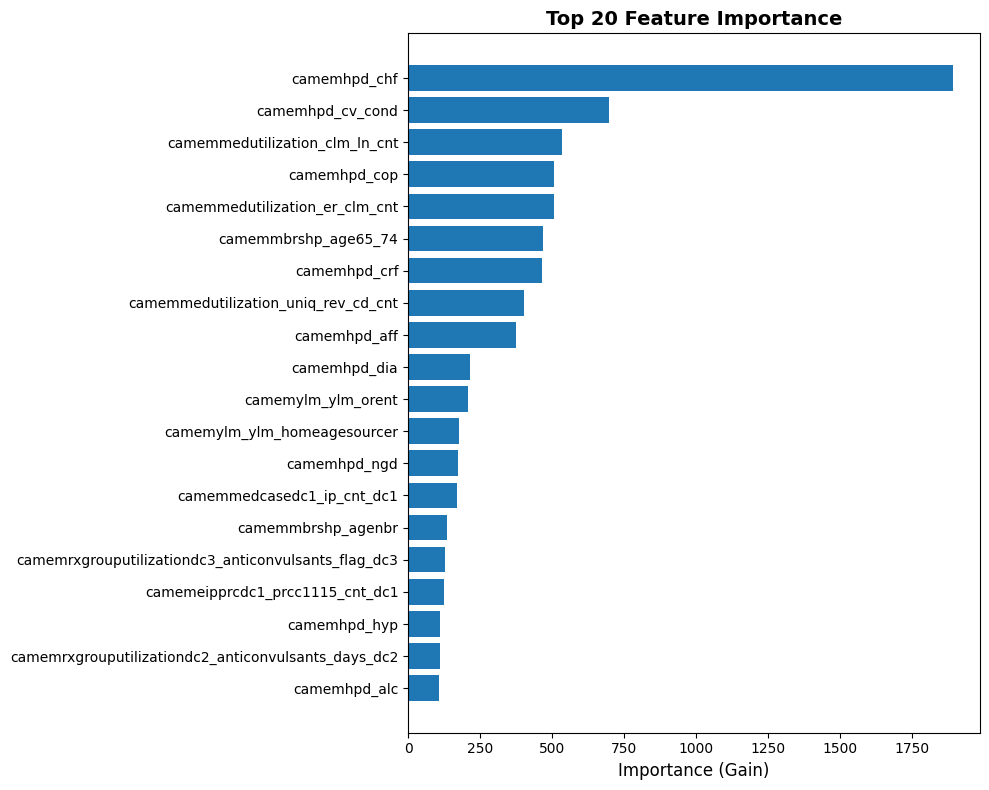


📊 FEATURE IMPORTANCE BY TYPE
                      sum  count        mean  percentage
feature_type                                            
Baseline      8833.159471     48  184.024156       100.0

📊 TOP 10 BASELINE FEATURES:
   camemhpd_chf                                          1891.31
   camemhpd_cv_cond                                       697.34
   camemmedutilization_clm_ln_cnt                         532.72
   camemhpd_cop                                           507.48
   camemmedutilization_er_clm_cnt                         505.22
   camemmbrshp_age65_74                                   469.71
   camemhpd_crf                                           465.16
   camemmedutilization_uniq_rev_cd_cnt                    403.90
   camemhpd_aff                                           375.68
   camemhpd_dia                                           214.80
   camemylm_ylm_orent                                     207.11
   camemylm_ylm_homeagesourcer                         

In [18]:
# Get feature importance
importance = bst.get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values('importance', ascending=False)

print("🎯 Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_n = 20
top_features = importance_df.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance (Gain)', fontsize=12)
plt.title(f'Top {top_n} Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================================================
# DETAILED FEATURE IMPORTANCE ANALYSIS
# ============================================================================================

# Categorize features by type
importance_df['feature_type'] = importance_df['feature'].apply(
    lambda x: 'Embedding' if x.startswith('embedding_') else 'Baseline'
)

# Calculate total importance by feature type
type_importance = importance_df.groupby('feature_type')['importance'].agg(['sum', 'count', 'mean'])
type_importance['percentage'] = (type_importance['sum'] / importance_df['importance'].sum()) * 100

print("\n" + "="*80)
print("📊 FEATURE IMPORTANCE BY TYPE")
print("="*80)
print(type_importance)

# Show top features from each category
print("\n📊 TOP 10 BASELINE FEATURES:")
baseline_features_imp = importance_df[importance_df['feature_type'] == 'Baseline'].head(50)
for idx, row in baseline_features_imp.iterrows():
    print(f"   {row['feature'][:50]:50s} {row['importance']:10.2f}")

if USE_EMBEDDINGS:
    print("\n📊 TOP 10 EMBEDDING FEATURES:")
    embedding_features_imp = importance_df[importance_df['feature_type'] == 'Embedding'].head(50)
    for idx, row in embedding_features_imp.iterrows():
        print(f"   {row['feature'][:50]:50s} {row['importance']:10.2f}")

# Plot importance distribution by type
if USE_BASELINE and USE_EMBEDDINGS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Pie chart
    axes[0].pie(type_importance['percentage'], labels=type_importance.index, autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Feature Importance Distribution', fontsize=14, fontweight='bold')
    
    # Bar chart by count
    axes[1].bar(type_importance.index, type_importance['count'])
    axes[1].set_ylabel('Number of Features', fontsize=12)
    axes[1].set_title('Feature Count by Type', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("✅ Feature importance analysis complete")
print("="*80)


## 9. Save Model Artifacts


In [19]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Define model version
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_version = f'medicare_ip_{exp_name}_v2_regularized'

# Save model
model_path = f'models/{model_version}_{timestamp}.model'
bst.save_model(model_path)
print(f"💾 Model saved: {model_path}")

# Save hyperparameters
params_path = f'models/{model_version}_{timestamp}_params.pkl'
pickle.dump(params, open(params_path, 'wb'))
print(f"   Parameters saved: {params_path}")

# Save feature list
features_path = f'models/{model_version}_{timestamp}_features.pkl'
pickle.dump(available_features, open(features_path, 'wb'))
print(f"   Features saved: {features_path}")

# Save feature importance
importance_path = f'models/{model_version}_{timestamp}_importance.csv'
importance_df.to_csv(importance_path, index=False)
print(f"   Feature importance saved: {importance_path}")

print(f"\n✅ All model artifacts saved successfully")


💾 Model saved: models/medicare_ip_medicare_ip_tabular_only_v2_regularized_20260122_013704.model
   Parameters saved: models/medicare_ip_medicare_ip_tabular_only_v2_regularized_20260122_013704_params.pkl
   Features saved: models/medicare_ip_medicare_ip_tabular_only_v2_regularized_20260122_013704_features.pkl
   Feature importance saved: models/medicare_ip_medicare_ip_tabular_only_v2_regularized_20260122_013704_importance.csv

✅ All model artifacts saved successfully


In [20]:
# Save metrics to CSV
metrics_csv_path = f'models/{model_version}_{timestamp}_metrics.csv'
metrics_df.to_csv(metrics_csv_path, index=False)
print(f"   Metrics saved: {metrics_csv_path}")

# Also save as pickle for easy reloading
metrics_pkl_path = f'models/{model_version}_{timestamp}_metrics.pkl'
pickle.dump(all_metrics, open(metrics_pkl_path, 'wb'))
print(f"   Metrics pickle saved: {metrics_pkl_path}")

print(f"\n✅ All artifacts saved successfully")


   Metrics saved: models/medicare_ip_medicare_ip_tabular_only_v2_regularized_20260122_013704_metrics.csv
   Metrics pickle saved: models/medicare_ip_medicare_ip_tabular_only_v2_regularized_20260122_013704_metrics.pkl

✅ All artifacts saved successfully


## 10. Model Summary


In [21]:
print("\n" + "="*80)
print("📊 MEDICARE IP MODEL TRAINING SUMMARY")
print("="*80)
print(f"\n🏷️  Model Version: {model_version}")
print(f"📅 Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\n📊 Data:")
print(f"   Total samples: {len(X):,}")
print(f"   Training samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation samples: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test samples: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"   Total features: {len(all_features)}")
if USE_BASELINE and USE_EMBEDDINGS:
    print(f"     - Baseline: {len(available_features)}")
    print(f"     - Embeddings: {len(embedding_features)}")
elif USE_BASELINE:
    print(f"     - Baseline only: {len(available_features)}")
elif USE_EMBEDDINGS:
    print(f"     - Embeddings only: {len(embedding_features)}")
print(f"   IP rate: {y.mean()*100:.2f}%")
print(f"\n🎯 Performance (AUC-ROC):")
print(f"   Training: {train_metrics['train_auc_roc']:.4f}")
print(f"   Validation: {val_metrics['val_auc_roc']:.4f}")
print(f"   Test: {test_metrics['test_auc_roc']:.4f}")
print(f"\n📈 Performance (AUC-PR):")
print(f"   Training: {train_metrics['train_auc_pr']:.4f}")
print(f"   Validation: {val_metrics['val_auc_pr']:.4f}")
print(f"   Test: {test_metrics['test_auc_pr']:.4f}")
print(f"\n🎯 Lift @ Top 1%:")
print(f"   Training: {train_metrics['train_lift_1pct']:.2f}x ({train_metrics['train_tp_1pct']} TP)")
print(f"   Validation: {val_metrics['val_lift_1pct']:.2f}x ({val_metrics['val_tp_1pct']} TP)")
print(f"   Test: {test_metrics['test_lift_1pct']:.2f}x ({test_metrics['test_tp_1pct']} TP)")
print(f"\n⚙️  Training:")
print(f"   Algorithm: XGBoost")
print(f"   Training time: {training_time:.1f}s ({training_time/60:.1f}m)")
print(f"   Best iteration: {bst.best_iteration}")
print(f"\n💾 Artifacts:")
print(f"   Model: {model_path}")
print(f"   Parameters: {params_path}")
print(f"   Features: {features_path}")
print(f"   Importance: {importance_path}")
print(f"   Metrics CSV: {metrics_csv_path}")
print(f"   Metrics PKL: {metrics_pkl_path}")
print(f"\n🎯 Top 5 Features:")
for idx, row in importance_df.head(5).iterrows():
    feat_type = "📊 Baseline" if row['feature'] in available_features else "🔢 Embedding"
    print(f"   {idx+1}. [{feat_type}] {row['feature']}: {row['importance']:.1f}")

# Check how many embeddings are in top features
top_20_features = importance_df.head(20)['feature'].tolist()
top_20_embeddings = [f for f in top_20_features if f in embedding_features]
top_20_baseline = [f for f in top_20_features if f in available_features]

print(f"\n📈 Top 20 Feature Breakdown:")
print(f"   Baseline features: {len(top_20_baseline)}/20 ({len(top_20_baseline)/20*100:.0f}%)")
print(f"   Embedding features: {len(top_20_embeddings)}/20 ({len(top_20_embeddings)/20*100:.0f}%)")

print("\n" + "="*80)
print("✅ TRAINING COMPLETE")
print("="*80)
print("\n📝 Comprehensive metrics generated:")
print("   ✅ AUC-ROC, AUC-PR, Brier Score")
print("   ✅ Lift @ 1%, 5%, 10%")
print("   ✅ Precision and True Positives at each percentile")
print("   ✅ Sample sizes and prevalence rates")
print("   ✅ Metrics for Train, Validation, and Test sets")
print("   ✅ Metrics exported to CSV for comparison")
print("\n📝 Next Steps:")
print("   1. Compare with other experiments (exp2b, exp6, tabular_only)")
print("   2. Analyze which embedding dimensions are most predictive")
print("   3. Test baseline-only and embeddings-only variants")
print("   4. Evaluate on out-of-time (OOT) data for temporal validation")
print("   5. Deploy best model to production")



📊 MEDICARE IP MODEL TRAINING SUMMARY

🏷️  Model Version: medicare_ip_medicare_ip_tabular_only_v2_regularized
📅 Training Date: 2026-01-22 01:37:04

📊 Data:
   Total samples: 3,059,018
   Training samples: 2,141,312 (70.0%)
   Validation samples: 458,853 (15.0%)
   Test samples: 458,853 (15.0%)
   Total features: 52
     - Baseline only: 52
   IP rate: 6.54%

🎯 Performance (AUC-ROC):
   Training: 0.7429
   Validation: 0.7396
   Test: 0.7436

📈 Performance (AUC-PR):
   Training: 0.2038
   Validation: 0.2000
   Test: 0.2011

🎯 Lift @ Top 1%:
   Training: 6.47x (9059 TP)
   Validation: 6.28x (1884 TP)
   Test: 6.22x (1866 TP)

⚙️  Training:
   Algorithm: XGBoost
   Training time: 496.8s (8.3m)
   Best iteration: 4999

💾 Artifacts:
   Model: models/medicare_ip_medicare_ip_tabular_only_v2_regularized_20260122_013704.model
   Parameters: models/medicare_ip_medicare_ip_tabular_only_v2_regularized_20260122_013704_params.pkl
   Features: models/medicare_ip_medicare_ip_tabular_only_v2_regularized